# 05: Jaynes-Cummings Ultra-strong Coupling

XXX Description

In this notebook we will use $\frac{1}{2} \sigma_z$ as the Hamiltonian of the atomic state, in order to emphasise the rise and decay of the system occupancy without the distraction of atom-cavity oscillations.

## Tasks

- XXX

# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import qutip
import numpy as np

## Helper functions

In [3]:
def jcm_h(wc, wa, g, N, atom):
    """ Construct the Jaynes-Cummings Hamiltonian (non-RWA). """
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
    sm = qutip.tensor(qutip.qeye(N), qutip.destroy(2))
    atom = qutip.tensor(qutip.qeye(N), atom)
    
    H = wc * a.dag() * a + wa * atom + g * (a.dag() + a) * (sm + sm.dag())
    return H

# XXX

In [4]:
# Dissipation parameters
kappa = 0.5 # 0.005  # cavity dissipation rate
gamma = 0.5 # 0.05  # atom dissipation rate
n_th_a = 0 # 5.0  # avg number of thermal bath excitation

In [5]:
# system parameters
wc = 1.0 #* 2 * np.pi  # cavity frequency
wa = 1.0 #* 2 * np.pi  # atom frequency
N = 8  # 15 # number of cavity fock states
# g = 0.05 * 2 * np.pi  # coupling strength
g_values = np.linspace(0.1, 0.5, 50)

# Atom hamiltonian
H_atom = 0.5 * qutip.sigmaz()

In [6]:
def jcm_c_ops(N, n_th_a):
    """ Return basic JCM collapse operators. """
    c_ops = []

    sm = qutip.tensor(qutip.qeye(N), qutip.sigmam())
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))

    # cavity relaxation
    rate = kappa * (1 + n_th_a)
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * a)

    # cavity excitation, if temperature > 0
    rate = kappa * n_th_a
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * a.dag())

    # qubit relaxation
    rate = gamma
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * sm)
        
    return c_ops

In [7]:
def jcm_mesolve(H, psi0, tlist, kappa, gamma, N, n_th_a, e_ops):
    """ Solve the given Jaynes-Cummngs module using the Master Equation solver. """
    options = qutip.Options(nsteps=15000, store_states=True, rtol=1e-12, atol=1e-12)

    c_ops = jcm_c_ops(N, n_th_a)

    result = qutip.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=e_ops, options=options)
    return result

In [8]:
def jcm_brmesolve(H, psi0, tlist, kappa, gamma, N, e_ops):
    """ Solve the given Jaynes-Cummings model use the Bloch-Redfield solver. """
    options = qutip.Options(nsteps=15000, store_states=True, rtol=1e-12, atol=1e-12)

    sx = qutip.tensor(qutip.qeye(N), qutip.sigmax())
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
    x = a + a.dag()

    cavity_spectrum = "0 if (w <= 0) else {kappa}".format(kappa=kappa)
    atom_spectrum = "0 if (w <= 0) else {gamma}".format(gamma=gamma)
    a_ops = [
        [x, cavity_spectrum],
        [sx, atom_spectrum],
    ]

    result = qutip.brmesolve(H, psi0, tlist, a_ops=a_ops, e_ops=e_ops, options=options)
    return result

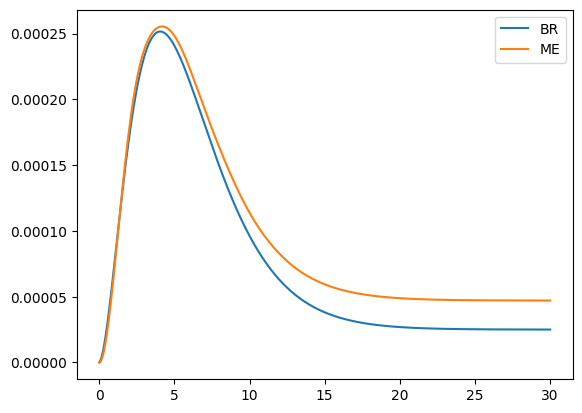

In [9]:
g = 0.01  # g_values[0]

tlist = np.linspace(0, 30, 500)

H = jcm_h(wc, wa, g, N, H_atom)

gnd_energy, gnd_state = H.groundstate()
psi0 = qutip.tensor(qutip.basis(N, 0), qutip.basis(2, 0))

sm = qutip.tensor(qutip.qeye(N), qutip.sigmam())
a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
e_ops = [a.dag() * a, sm.dag() * sm]

result_br = jcm_brmesolve(H, psi0, tlist, kappa, gamma, N, e_ops=e_ops)
result_me = jcm_mesolve(H, psi0, tlist, kappa, gamma, N, n_th_a, e_ops=e_ops)


plt.plot(tlist, result_br.expect[0], label="BR")
plt.plot(tlist, result_me.expect[0], label="ME")
plt.legend();